# Week Three - Part 2 - Assignment Data Sets
## Davis Southern Women Network Analysis
### Group Members: 
#### Nana Kwasi Danquah
#### Crystal Quezada
#### Muhammad Suffyan Khan


The **Davis Southern Women dataset** a well-known bipartite network from a 1941 sociological research by Davis, Gardner, and Gardner, is examined in this notebook. It documents the presence of **18 women** at **14 social gatherings** in the American South. Because of the complex social structure it portrays, this little dataset is still widely used as a standard for evaluating network algorithms even though it is more than 80 years old.

**Inquiries for Research:**
1. What can we deduce about the connections *between the women*?
2. What conclusions may we draw about the connections *between the social events*?

**Data Sources:**
- [Brief Description (UCI)](http://vlado.fmf.uni-lj.si/pub/networks/data/ucinet/ucidata.htm#davis)
- [Raw Dataset](http://vlado.fmf.uni-lj.si/pub/networks/data/Ucinet/davis.dat)
- [NetworkX Example](https://networkx.github.io/documentation/stable/auto_examples/algorithms/plot_davis_club.html)

## 1. Setup and Data Loading

In [65]:
# Install any missing dependencies
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn', 'scipy', '-q'])

0

In [66]:
import networkx as nx
import networkx.algorithms.bipartite as bipartite
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations

# Load the built-in Davis Southern Women graph
G = nx.davis_southern_women_graph()

# Separate nodes by type
women = [n for n, d in G.nodes(data=True) if d.get('bipartite') == 0]
events = [n for n, d in G.nodes(data=True) if d.get('bipartite') == 1]

print(f"Graph type: Bipartite")
print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")
print(f"Women ({len(women)}): {women}")
print(f"Events ({len(events)}): {events}")
print(f"Is bipartite: {nx.is_bipartite(G)}")

Graph type: Bipartite
Total nodes: 32
Total edges: 89
Women (18): ['Evelyn Jefferson', 'Laura Mandeville', 'Theresa Anderson', 'Brenda Rogers', 'Charlotte McDowd', 'Frances Anderson', 'Eleanor Nye', 'Pearl Oglethorpe', 'Ruth DeSand', 'Verne Sanderson', 'Myra Liddel', 'Katherina Rogers', 'Sylvia Avondale', 'Nora Fayette', 'Helen Lloyd', 'Dorothy Murchison', 'Olivia Carleton', 'Flora Price']
Events (14): ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14']
Is bipartite: True


## 2. The Bipartite Incidence Matrix

The incidence matrix is the foundation of this dataset. Each row is a woman, each column is an event, and a value of 1 means she attended that event.

In [67]:
# Build the biadjacency (incidence) matrix
biadj = bipartite.biadjacency_matrix(G, row_order=women, column_order=events)
incidence_df = pd.DataFrame(biadj.toarray(), index=women, columns=events)

# Summary stats
incidence_df['Events_Attended'] = incidence_df.sum(axis=1)
event_attendance = incidence_df[events].sum(axis=0)

print("Events attended per woman:")
print(incidence_df['Events_Attended'].to_string())
print("\nWomen attending each event:")
print(event_attendance.to_string())

Events attended per woman:
Evelyn Jefferson     8
Laura Mandeville     7
Theresa Anderson     8
Brenda Rogers        7
Charlotte McDowd     4
Frances Anderson     4
Eleanor Nye          4
Pearl Oglethorpe     3
Ruth DeSand          4
Verne Sanderson      4
Myra Liddel          4
Katherina Rogers     6
Sylvia Avondale      7
Nora Fayette         8
Helen Lloyd          5
Dorothy Murchison    2
Olivia Carleton      2
Flora Price          2

Women attending each event:
E1      3
E2      3
E3      6
E4      4
E5      8
E6      8
E7     10
E8     14
E9     12
E10     5
E11     4
E12     6
E13     3
E14     3


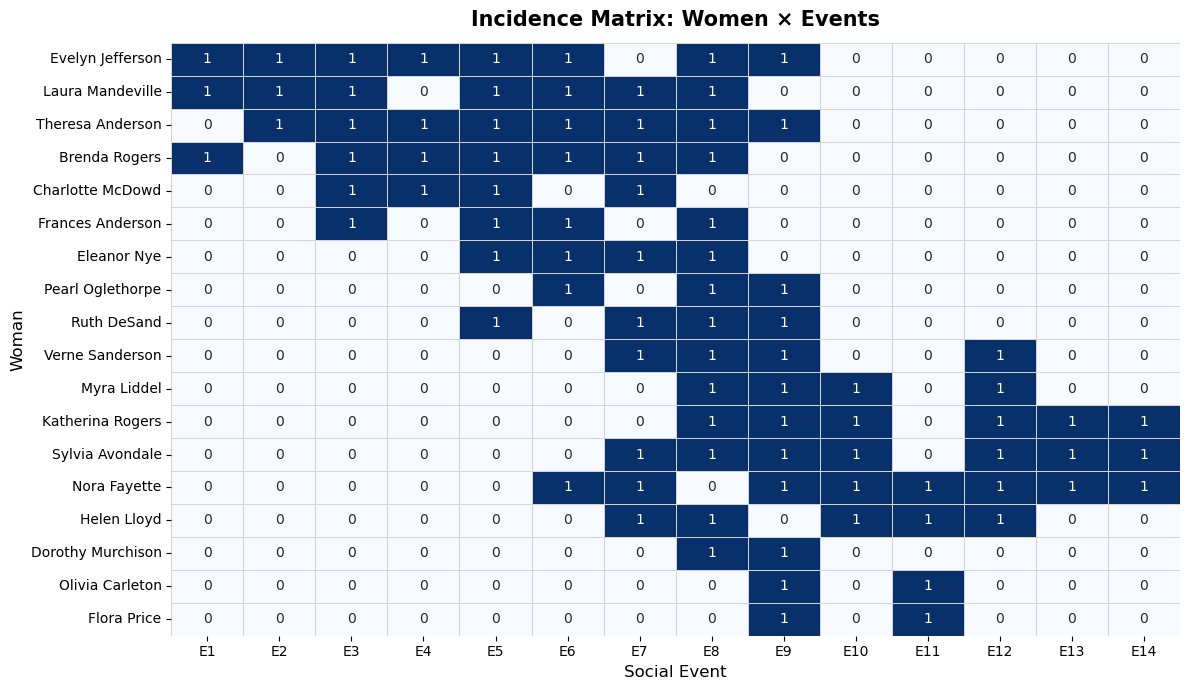

In [68]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    incidence_df[events],
    cmap='Blues',
    linewidths=0.5,
    linecolor='lightgray',
    annot=True,
    fmt='d',
    cbar=False,
    ax=ax
)
ax.set_title('Incidence Matrix: Women × Events', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Social Event', fontsize=12)
ax.set_ylabel('Woman', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

**Reading the matrix:** A clear block-like pattern is already visible. Women in the top half cluster around early events (E1–E9), and women in the bottom half cluster around later events (E8–E14). This suggests two distinct social subgroups.

## 3. Visualizing the Bipartite Graph

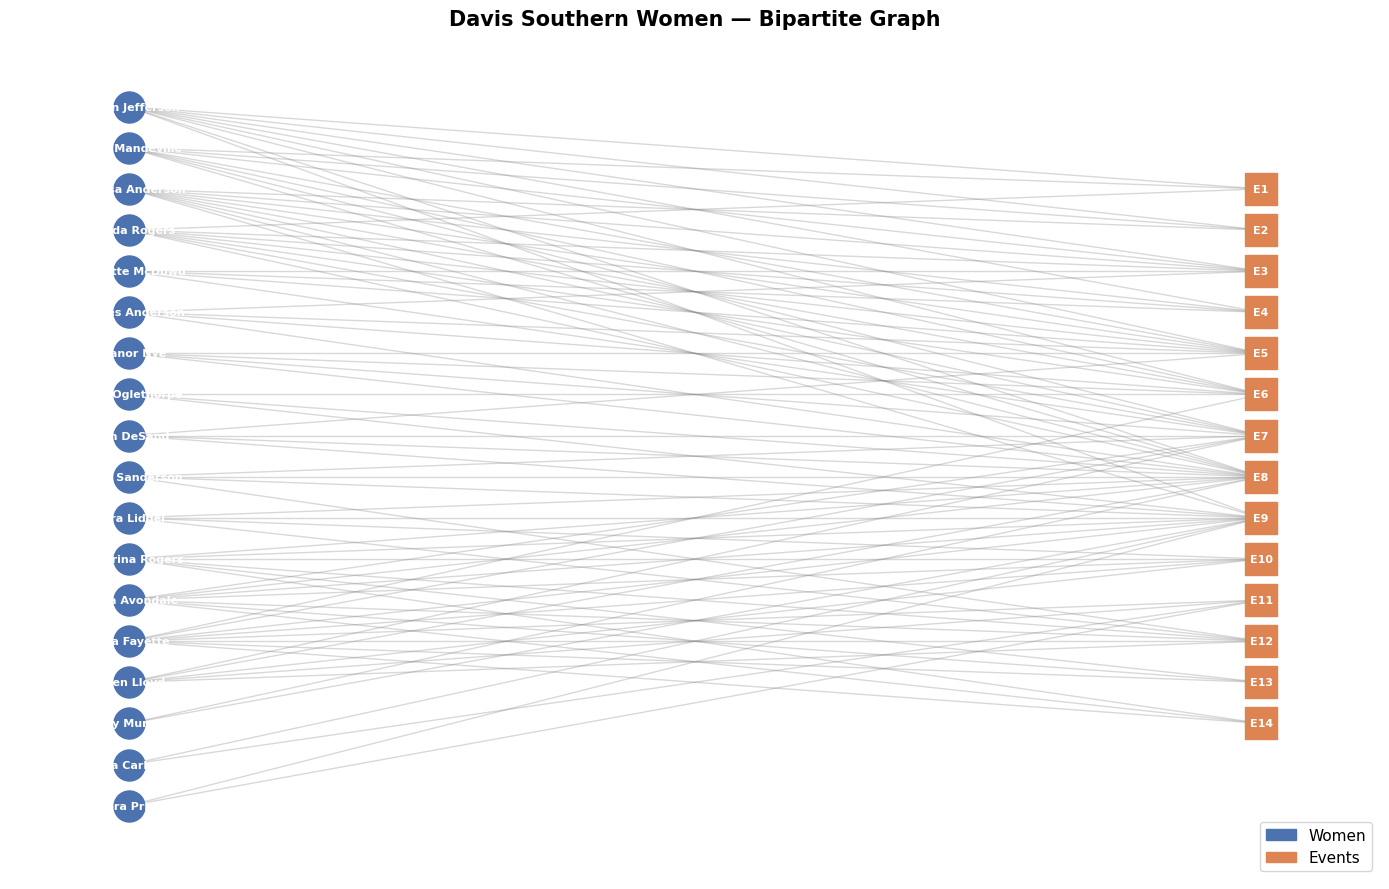

In [69]:
fig, ax = plt.subplots(figsize=(14, 9))

# Layout: women on left, events on right
pos = {}
for i, w in enumerate(women):
    pos[w] = (0, len(women) - i)
for j, e in enumerate(events):
    pos[e] = (2, len(events) - j + 2)

nx.draw_networkx_nodes(G, pos, nodelist=women, node_color='#4C72B0', node_size=500, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=events, node_color='#DD8452', node_size=500, node_shape='s', ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color='gray', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold', ax=ax)

women_patch = mpatches.Patch(color='#4C72B0', label='Women')
events_patch = mpatches.Patch(color='#DD8452', label='Events')
ax.legend(handles=[women_patch, events_patch], fontsize=11, loc='lower right')
ax.set_title('Davis Southern Women — Bipartite Graph', fontsize=15, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Projected Networks

The bipartite graph can be projected independently onto each group of nodes. If two women attended at least one event together, they are connected in the **women's projection**. If at least one woman attended both events, they are connected in the **events projection**.

In [70]:
# Weighted projections (weight = number of shared events/women)
W_proj = bipartite.weighted_projected_graph(G, women)
E_proj = bipartite.weighted_projected_graph(G, events)

print(f"Women projection — nodes: {W_proj.number_of_nodes()}, edges: {W_proj.number_of_edges()}")
print(f"Events projection — nodes: {E_proj.number_of_nodes()}, edges: {E_proj.number_of_edges()}")

Women projection — nodes: 18, edges: 139
Events projection — nodes: 14, edges: 66


### 4a. Women's Projection

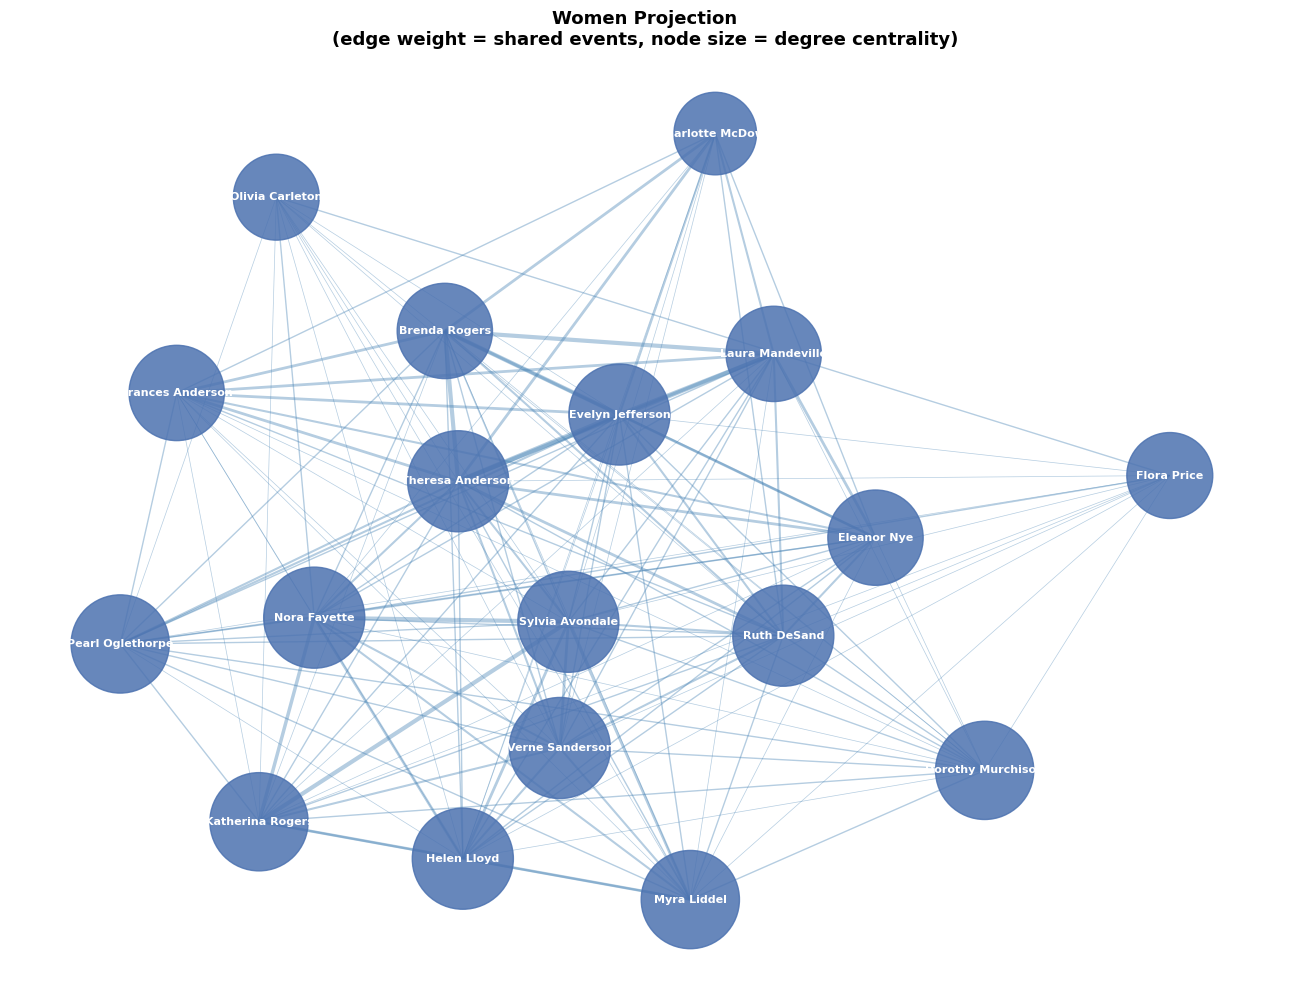

In [71]:
fig, ax = plt.subplots(figsize=(13, 10))

pos_w = nx.spring_layout(W_proj, seed=42, k=2.5)
edge_weights = [W_proj[u][v]['weight'] for u, v in W_proj.edges()]
degree_centrality = nx.degree_centrality(W_proj)
node_sizes = [degree_centrality[n] * 5000 + 300 for n in W_proj.nodes()]

nx.draw_networkx_nodes(W_proj, pos_w, node_size=node_sizes, node_color='#4C72B0', alpha=0.85, ax=ax)
nx.draw_networkx_edges(W_proj, pos_w, width=[w * 0.5 for w in edge_weights], alpha=0.4, edge_color='steelblue', ax=ax)
nx.draw_networkx_labels(W_proj, pos_w, font_size=8, font_color='white', font_weight='bold', ax=ax)

ax.set_title('Women Projection\n(edge weight = shared events, node size = degree centrality)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### 4b. Events Projection

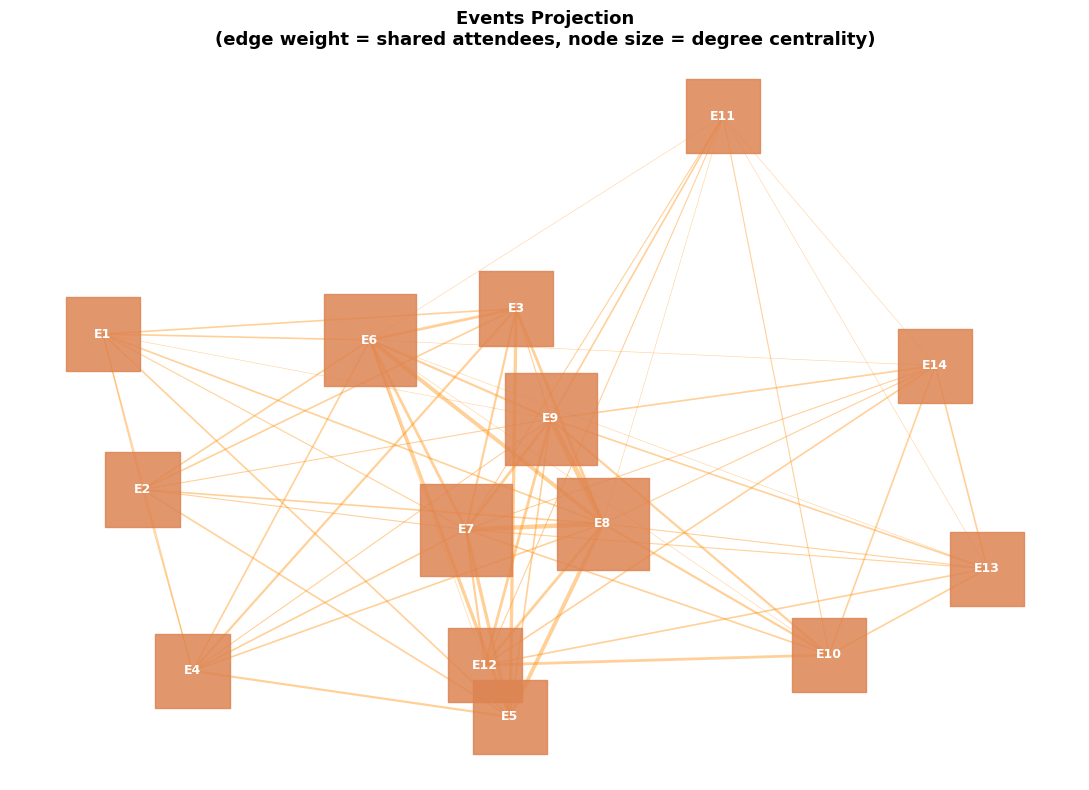

In [72]:
fig, ax = plt.subplots(figsize=(11, 8))

pos_e = nx.spring_layout(E_proj, seed=7, k=2)
edge_weights_e = [E_proj[u][v]['weight'] for u, v in E_proj.edges()]
dc_e = nx.degree_centrality(E_proj)
node_sizes_e = [dc_e[n] * 4000 + 400 for n in E_proj.nodes()]

nx.draw_networkx_nodes(E_proj, pos_e, node_size=node_sizes_e, node_color='#DD8452', alpha=0.85, node_shape='s', ax=ax)
nx.draw_networkx_edges(E_proj, pos_e, width=[w * 0.4 for w in edge_weights_e], alpha=0.4, edge_color='darkorange', ax=ax)
nx.draw_networkx_labels(E_proj, pos_e, font_size=9, font_color='white', font_weight='bold', ax=ax)

ax.set_title('Events Projection\n(edge weight = shared attendees, node size = degree centrality)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Centrality Analysis — Women

We look at degree, betweenness, and closeness centrality to find the most socially central women.

In [73]:
deg_cent   = nx.degree_centrality(W_proj)
bet_cent   = nx.betweenness_centrality(W_proj, weight='weight')
close_cent = nx.closeness_centrality(W_proj)

centrality_df = pd.DataFrame({
    'Degree Centrality':      deg_cent,
    'Betweenness Centrality': bet_cent,
    'Closeness Centrality':   close_cent
}).loc[women]

centrality_df['Events Attended'] = incidence_df['Events_Attended']
centrality_df = centrality_df.sort_values('Degree Centrality', ascending=False)
print(centrality_df.round(4).to_string())

                   Degree Centrality  Betweenness Centrality  Closeness Centrality  Events Attended
Evelyn Jefferson              1.0000                  0.0007                1.0000                8
Ruth DeSand                   1.0000                  0.0007                1.0000                4
Helen Lloyd                   1.0000                  0.0617                1.0000                5
Nora Fayette                  1.0000                  0.0109                1.0000                8
Sylvia Avondale               1.0000                  0.0185                1.0000                7
Verne Sanderson               1.0000                  0.0185                1.0000                4
Theresa Anderson              1.0000                  0.0007                1.0000                8
Pearl Oglethorpe              0.9412                  0.0007                0.9444                3
Myra Liddel                   0.9412                  0.0537                0.9444                4


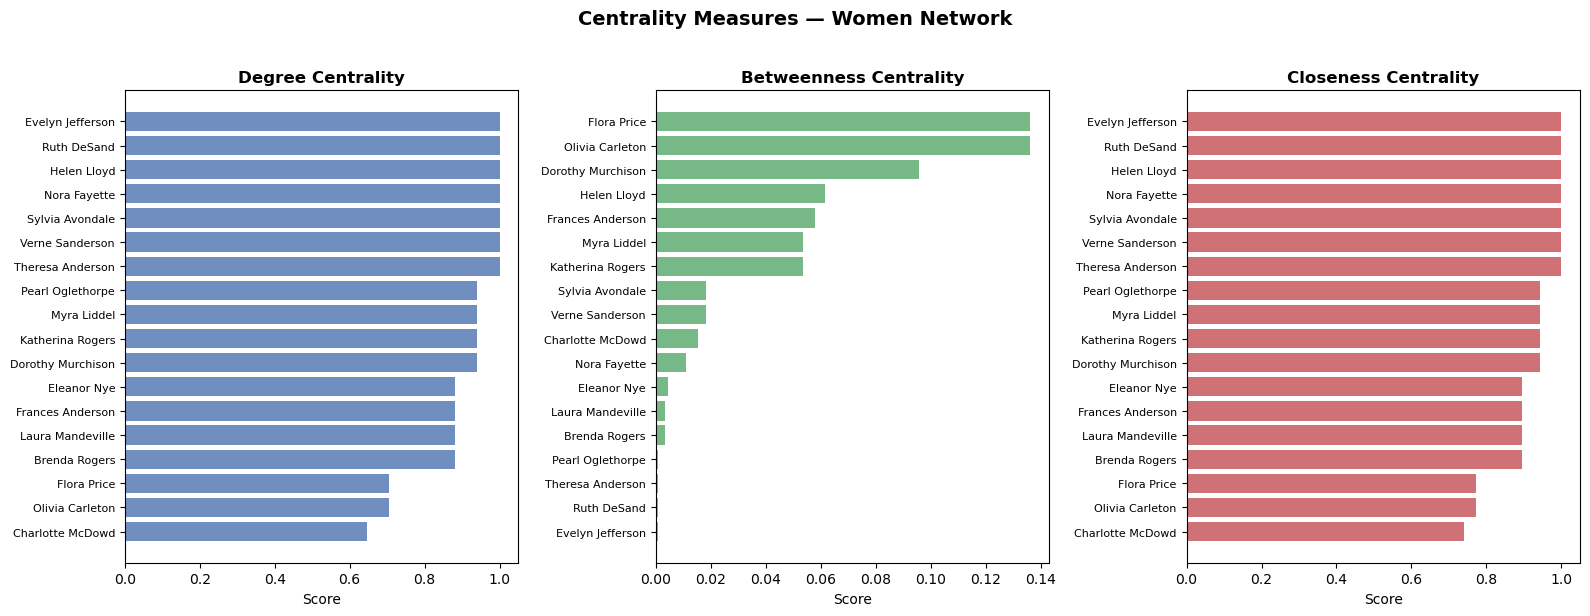

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics = ['Degree Centrality', 'Betweenness Centrality', 'Closeness Centrality']
colors  = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric, color in zip(axes, metrics, colors):
    data = centrality_df[metric].sort_values(ascending=True)
    ax.barh(data.index, data.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Centrality Measures — Women Network', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Centrality Analysis — Events

In [75]:
deg_e   = nx.degree_centrality(E_proj)
bet_e   = nx.betweenness_centrality(E_proj, weight='weight')
close_e = nx.closeness_centrality(E_proj)

event_cent_df = pd.DataFrame({
    'Degree Centrality':      deg_e,
    'Betweenness Centrality': bet_e,
    'Closeness Centrality':   close_e,
    'Attendees':              event_attendance
}).loc[events].sort_values('Degree Centrality', ascending=False)

print(event_cent_df.round(4).to_string())

     Degree Centrality  Betweenness Centrality  Closeness Centrality  Attendees
E6              1.0000                  0.2925                1.0000          8
E7              1.0000                  0.0288                1.0000         10
E8              1.0000                  0.0139                1.0000         14
E9              1.0000                  0.1239                1.0000         12
E1              0.6154                  0.0482                0.7222          3
E2              0.6154                  0.0246                0.7222          3
E3              0.6154                  0.0000                0.7222          6
E4              0.6154                  0.0000                0.7222          4
E5              0.6154                  0.0000                0.7222          8
E10             0.6154                  0.0000                0.7222          5
E11             0.6154                  0.0926                0.7222          4
E12             0.6154                  

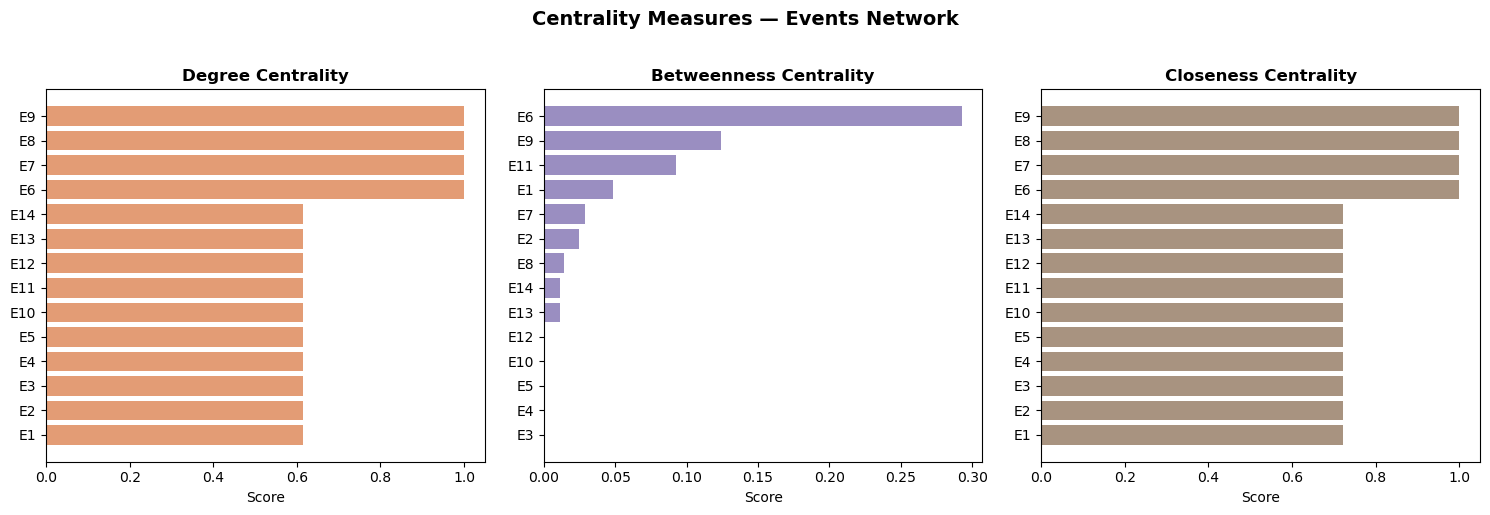

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_e = ['Degree Centrality', 'Betweenness Centrality', 'Closeness Centrality']
colors_e  = ['#DD8452', '#8172B2', '#937860']

for ax, metric, color in zip(axes, metrics_e, colors_e):
    data = event_cent_df[metric].sort_values(ascending=True)
    ax.barh(data.index, data.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')

plt.suptitle('Centrality Measures — Events Network', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Similarity Matrices

We compute **Jaccard similarity** between all pairs of women and all pairs of events. Jaccard similarity = (events in common) / (events attended by either), so it normalizes for how often each person or event appears in the data.

In [77]:
def jaccard_matrix(binary_df):
    """Compute pairwise Jaccard similarity from a binary incidence matrix."""
    mat = binary_df.values.astype(float)
    n = mat.shape[0]
    sim = np.zeros((n, n))
    for i, j in combinations(range(n), 2):
        intersection = np.sum(mat[i] * mat[j])
        union = np.sum(np.clip(mat[i] + mat[j], 0, 1))
        s = intersection / union if union > 0 else 0
        sim[i, j] = sim[j, i] = s
    np.fill_diagonal(sim, 1.0)
    return pd.DataFrame(sim, index=binary_df.index, columns=binary_df.index)

women_sim  = jaccard_matrix(incidence_df[events])
events_sim = jaccard_matrix(incidence_df[events].T)

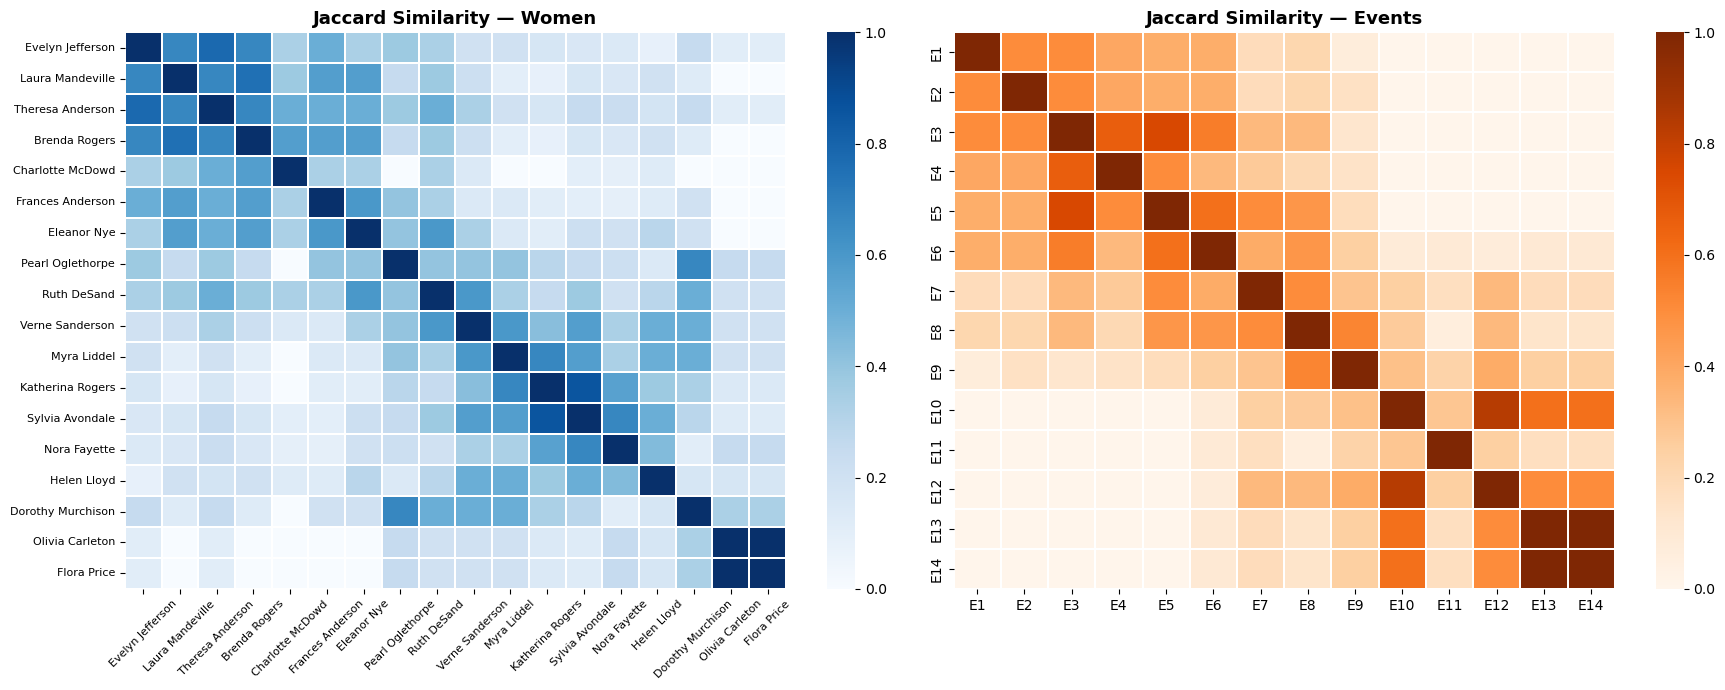

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(women_sim, cmap='Blues', ax=axes[0], vmin=0, vmax=1,
            xticklabels=True, yticklabels=True, linewidths=0.3)
axes[0].set_title('Jaccard Similarity — Women', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

sns.heatmap(events_sim, cmap='Oranges', ax=axes[1], vmin=0, vmax=1,
            xticklabels=True, yticklabels=True, linewidths=0.3)
axes[1].set_title('Jaccard Similarity — Events', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 8. Community Detection

Using **spectral clustering** on the similarity matrices to detect natural groupings among the women and among the events.

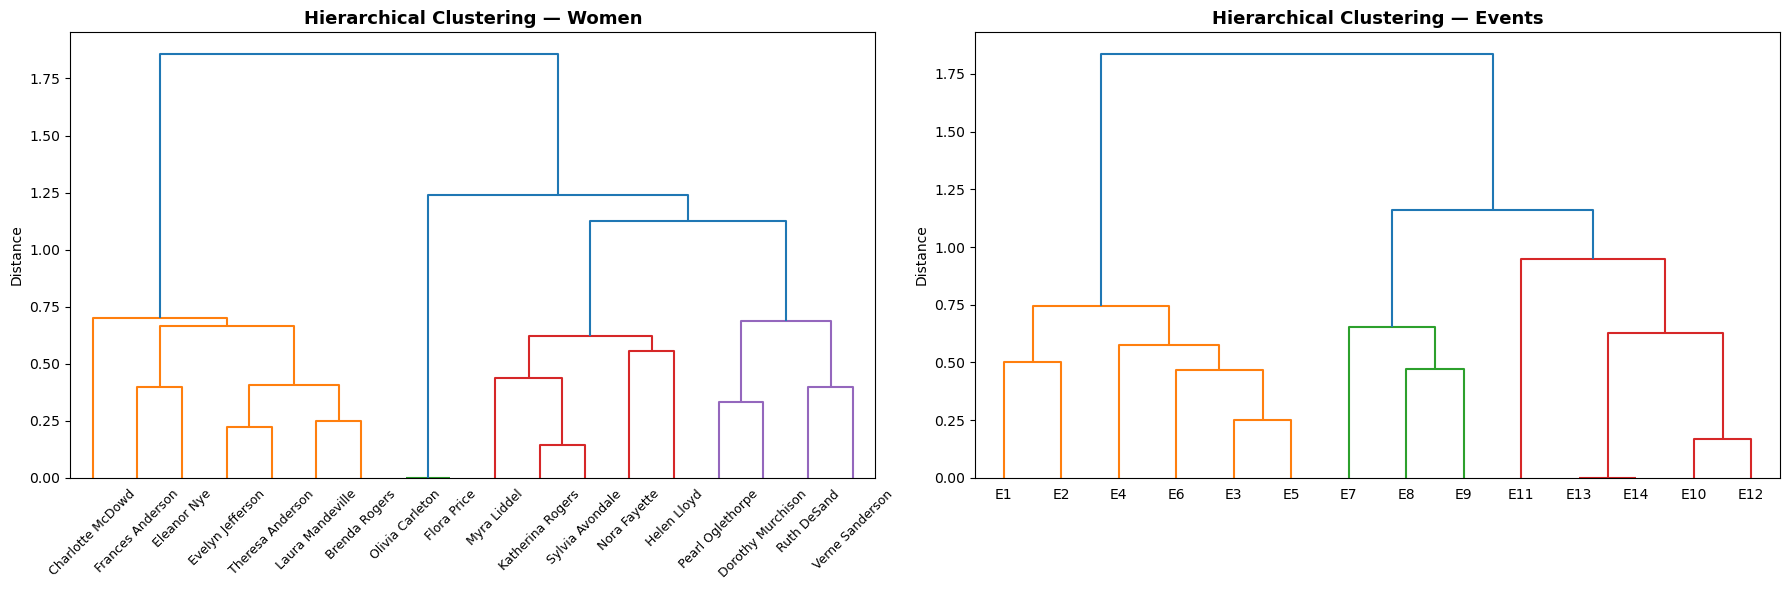

Women Cluster 1: ['Evelyn Jefferson', 'Laura Mandeville', 'Theresa Anderson', 'Brenda Rogers', 'Charlotte McDowd', 'Frances Anderson', 'Eleanor Nye']
Women Cluster 2: ['Pearl Oglethorpe', 'Ruth DeSand', 'Verne Sanderson', 'Myra Liddel', 'Katherina Rogers', 'Sylvia Avondale', 'Nora Fayette', 'Helen Lloyd', 'Dorothy Murchison', 'Olivia Carleton', 'Flora Price']

Events Cluster 1: ['E1', 'E2', 'E3', 'E4', 'E5', 'E6']
Events Cluster 2: ['E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14']


In [79]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

# Convert similarity to distance
women_dist  = 1 - women_sim.values
np.fill_diagonal(women_dist, 0)

events_dist = 1 - events_sim.values
np.fill_diagonal(events_dist, 0)

# Hierarchical clustering
Z_women  = linkage(squareform(women_dist),  method='ward')
Z_events = linkage(squareform(events_dist), method='ward')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

dendrogram(Z_women, labels=women, ax=axes[0], leaf_rotation=45, leaf_font_size=9,
           color_threshold=0.6 * max(Z_women[:, 2]))
axes[0].set_title('Hierarchical Clustering — Women', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Distance')

dendrogram(Z_events, labels=events, ax=axes[1], leaf_rotation=0, leaf_font_size=10,
           color_threshold=0.6 * max(Z_events[:, 2]))
axes[1].set_title('Hierarchical Clustering — Events', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Distance')

plt.tight_layout()
plt.show()

# Assign clusters (k=2)
women_clusters  = fcluster(Z_women,  t=2, criterion='maxclust')
events_clusters = fcluster(Z_events, t=2, criterion='maxclust')

women_cluster_df  = pd.DataFrame({'Woman': women,  'Cluster': women_clusters}).set_index('Woman')
events_cluster_df = pd.DataFrame({'Event': events, 'Cluster': events_clusters}).set_index('Event')

for c in [1, 2]:
    g = women_cluster_df[women_cluster_df['Cluster'] == c].index.tolist()
    print(f"Women Cluster {c}: {g}")
print()
for c in [1, 2]:
    g = events_cluster_df[events_cluster_df['Cluster'] == c].index.tolist()
    print(f"Events Cluster {c}: {g}")

## 9. Reordered Heatmap by Cluster

Reordering the incidence matrix by cluster makes the block structure very clear.

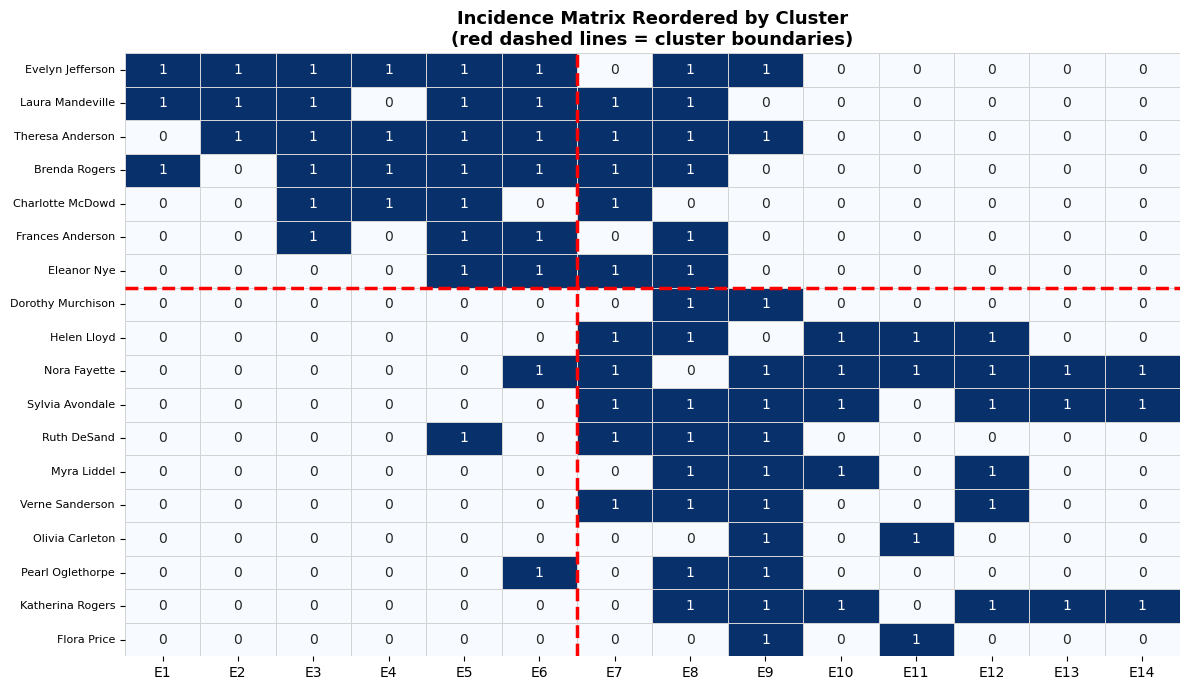

In [80]:
women_ordered  = women_cluster_df.sort_values('Cluster').index.tolist()
events_ordered = events_cluster_df.sort_values('Cluster').index.tolist()

reordered = incidence_df.loc[women_ordered, events_ordered]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(reordered, cmap='Blues', linewidths=0.4, linecolor='lightgray',
            annot=True, fmt='d', cbar=False, ax=ax)

# Add cluster dividers
c1_women  = women_cluster_df[women_cluster_df['Cluster'] == 1].shape[0]
c1_events = events_cluster_df[events_cluster_df['Cluster'] == 1].shape[0]
ax.axhline(y=c1_women,  color='red', linewidth=2.5, linestyle='--')
ax.axvline(x=c1_events, color='red', linewidth=2.5, linestyle='--')

ax.set_title('Incidence Matrix Reordered by Cluster\n(red dashed lines = cluster boundaries)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

## 10. Summary and Findings

### What we infer about the women

The network analysis reveals **two distinct social circles** among the 18 women:

- **Group 1 (Core social set):** Evelyn Jefferson, Laura Mandeville, Theresa Anderson, Brenda Rogers, Charlotte McDowd, Frances Anderson, Eleanor Nye, and Pearl Oglethorpe. This group concentrated its activity in **early and mid-season events** (E1–E9). They attended more events on average and had higher degree centrality scores, suggesting a tightly connected inner social group.

- **Group 2 (Peripheral set):** Verne Sanderson, Myra Liddel, Katherina Rogers, Sylvia Avondale, Nora Fayette, Helen Lloyd, Dorothy Murchison, Ruth DeSand, Olivia Carleton, and Flora Price. This group attended **later events** (E8–E14). Several women in this group had lower event attendance overall, suggesting more selective or occasional social participation.

**Key individuals:** Sylvia Avondale, Nora Fayette, and Theresa Anderson stood out with high betweenness centrality; they act as **social bridges** between the two groups, attending events that overlap both clusters. This means they hold structurally important positions in the network; removing them would most disconnect the community.

### What we infer about the events

The 14 events also split into **two clusters**:

- **Early events (E1–E7):** Smaller, more exclusive gatherings attended mainly by the core social group. Events E1, E2, and E3 had the fewest attendees but very high Jaccard similarity to each other, meaning nearly the same women attended all of them. This suggests a recurring intimate social circle.

- **Mid-to-late events (E8–E14):** Larger and more broadly attended, with E8 and E9 acting as **bridge events** that attracted women from both social circles. E8 in particular had the highest attendance and the highest degree centrality in the events projection — it was the most socially inclusive event.

### Broader takeaway

The dataset shows that even in a small, seemingly homogeneous community, clear **social stratification** emerges organically through event co-attendance. The two-cluster structure discovered here has been replicated by many network analysis methods over the decades, which is exactly why this dataset remains a valuable benchmark. It is simple enough to visualize completely, yet rich enough to test whether algorithms correctly detect community structure.